In [3]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame 
import matplotlib as mplt
from matplotlib import pyplot as plt

C:\Users\NOUR\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
df = pd.read_csv('E:/NOUR/Documents/PFE/data/supermarket_sales - Sheet1.csv', sep= ',')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.dtypes


Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [5]:
df.isna().any()

Invoice ID                 False
Branch                     False
City                       False
Customer type              False
Gender                     False
Product line               False
Unit price                 False
Quantity                   False
Tax 5%                     False
Total                      False
Date                       False
Time                       False
Payment                    False
cogs                       False
gross margin percentage    False
gross income               False
Rating                     False
dtype: bool

In [6]:
# how many purchases were made by men and how many by women
df.value_counts('Gender')


Gender
Female    501
Male      499
Name: count, dtype: int64

In [7]:
df.groupby(by='Gender').count()

,Invoice ID,Branch,City,Customer type,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
Gender,,,,,,,,,,,,,,,,
Female,501,501,501,501,501,501,501,501,501,501,501,501,501,501,501,501
Male,499,499,499,499,499,499,499,499,499,499,499,499,499,499,499,499


In [8]:
#  what the unique product lines are
df.value_counts('Product line')

Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

In [18]:
df['Date'] = pd.to_datetime(df['Date'])
dfDate = df.groupby(by='Date').sum()
print(dfDate['Total'])


Date
2019-01-01    4745.1810
2019-01-02    1945.5030
2019-01-03    2078.1285
2019-01-04    1623.6885
2019-01-05    3536.6835
                ...    
2019-03-26    1962.5130
2019-03-27    2902.8195
2019-03-28    2229.4020
2019-03-29    4023.2430
2019-03-30    4487.0595
Name: Total, Length: 89, dtype: float64


In [ ]:
#  a linear graph of the sum of all purchases for the day.

Text(0.5, 1.0, 'Total of all Purchases for the Day')

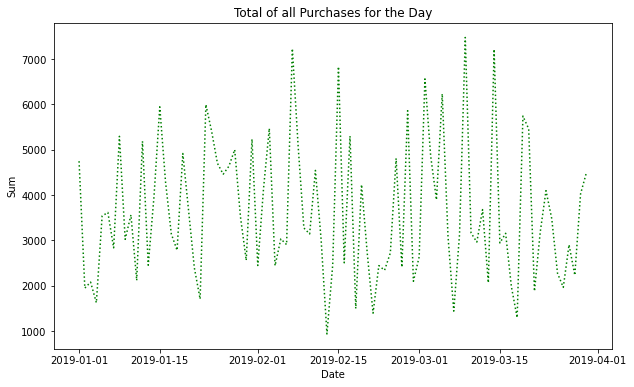

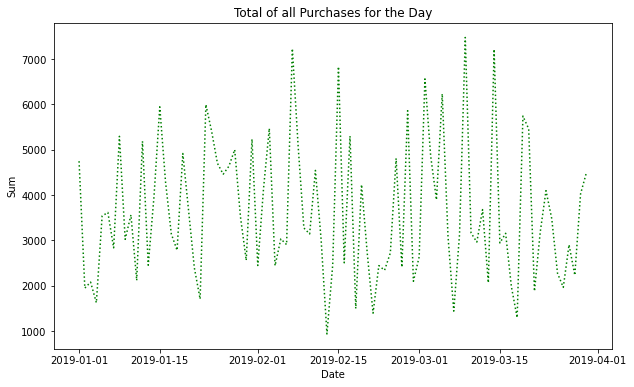

In [19]:

plt.figure(figsize=(10, 6))
plt.plot(dfDate['Total'], color = 'green', linestyle = ':')
plt.xlabel("Date")
plt.ylabel("Sum")
plt.title("Total of all Purchases for the Day")# Let's plot a linear graph of the sum of all purchases for the day.
plt.figure(figsize=(10, 6))
plt.plot(dfDate['Total'], color = 'green', linestyle = ':')
plt.xlabel("Date")
plt.ylabel("Sum")
plt.title("Total of all Purchases for the Day")

In [ ]:
#  plot the number of daily sales in each branch (Branch).


In [20]:
df_Branch = pd.pivot_table(df, index = "Date", columns = "Branch",
                          values="Quantity",
                          aggfunc= np.sum)
df_Branch

Branch,A,B,C
Date,,,
2019-01-01,37.0,24.0,20.0
2019-01-02,7.0,31.0,10.0
2019-01-03,19.0,15.0,3.0
2019-01-04,15.0,8.0,9.0
2019-01-05,27.0,11.0,17.0
...,...,...,...
2019-03-26,25.0,13.0,14.0
2019-03-27,22.0,14.0,9.0
2019-03-28,35.0,3.0,10.0


array([<matplotlib.axes._subplots.AxesSubplot object at 0x000001F7EFCF2EE0>,
      dtype=object)

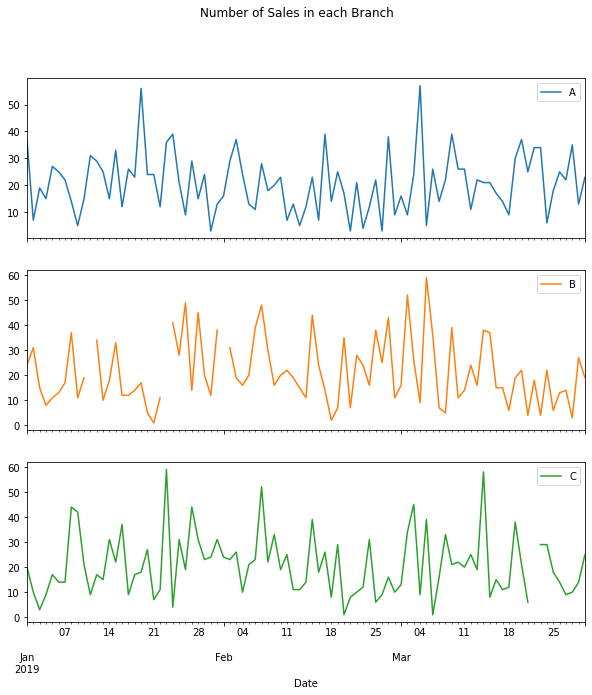

In [21]:
df_Branch.plot(kind='line', subplots=True, title="Number of Sales in each Branch",
        figsize=(10, 10)) 

In [ ]:
 graphs easier to understand.

In [22]:

df_Branch = pd.pivot_table(df, index= "Date", columns= "Branch", values="Quantity", aggfunc= np.sum)
df_Branch['Moving Ave_A'] = df_Branch['A'].rolling(window= 10, min_periods= 1).mean()
df_Branch['Moving Ave_B'] = df_Branch['B'].rolling(window= 5, min_periods= 1, center=False).mean()
df_Branch['Moving Ave_C'] = df_Branch['C'].rolling(window= 3, min_periods= 0, center=False).mean()
df_Branch

Branch,A,B,C,Moving Ave_A,Moving Ave_B,Moving Ave_C
Date,,,,,,
2019-01-01,37.0,24.0,20.0,37.0,24.000000,20.000000
2019-01-02,7.0,31.0,10.0,22.0,27.500000,15.000000
2019-01-03,19.0,15.0,3.0,21.0,23.333333,11.000000
2019-01-04,15.0,8.0,9.0,19.5,19.500000,7.333333
2019-01-05,27.0,11.0,17.0,21.0,17.800000,9.666667
...,...,...,...,...,...,...
2019-03-26,25.0,13.0,14.0,23.2,12.600000,20.333333
2019-03-27,22.0,14.0,9.0,24.0,11.800000,13.666667
2019-03-28,35.0,3.0,10.0,26.6,11.600000,11.000000


array([<matplotlib.axes._subplots.AxesSubplot object at 0x000001F7F3481130>,
      dtype=object)

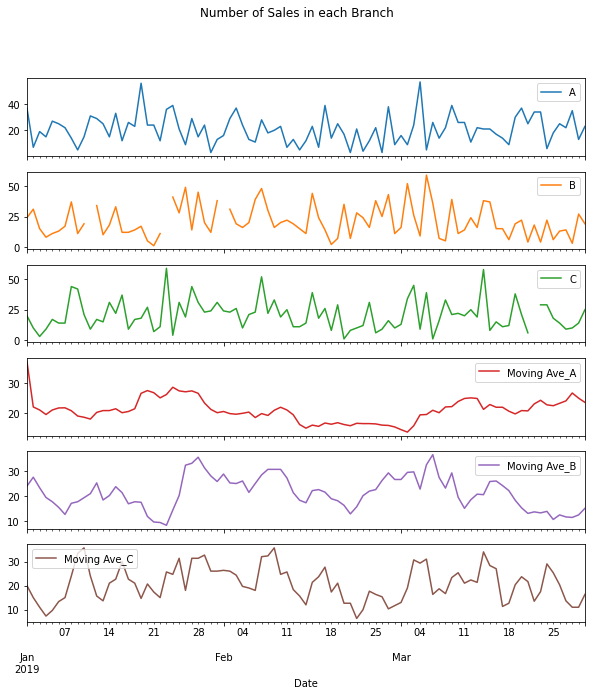

In [23]:
df_Branch.plot(kind='line', subplots=True, title="Number of Sales in each Branch", figsize=(10, 10))

In [24]:
#  what city each of the branches is located in.
df.Payment1 = pd.pivot_table(df, index = 'Payment', columns = 'City', values="Quantity", aggfunc = sum) #['min', 'max', 'mean', 'median','sum'])
df.Payment1

<ipython-input-24-dc03c5472df7>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.Payment1 = pd.pivot_table(df, index = 'Payment', columns = 'City', values="Quantity", aggfunc = sum) #['min', 'max', 'mean', 'median','sum'])


City,Mandalay,Naypyitaw,Yangon
Payment,,,
Cash,628,696,572
Credit card,599,543,580
Ewallet,593,592,707


In [25]:
df.Payment1['sum_row'] = df.Payment1.apply(lambda x: (x[0]+x[1]+x[2]), axis=1)
df.Payment1.loc['sum_col'] = df.Payment1.apply(lambda x: (x[0]+x[1]+x[2]), axis=0)
df.Payment1.loc['percent_Cash'] = df.Payment1.apply(lambda x: (x[0]/x[3]*100), axis=0)
df.Payment1.loc['percent_Ewallet'] = df.Payment1.apply(lambda x: (x[2]/x[3]*100), axis=0)
df.Payment1

City,Mandalay,Naypyitaw,Yangon,sum_row
Payment,,,,
Cash,628.000000,696.000000,572.000000,1896.000000
Credit card,599.000000,543.000000,580.000000,1722.000000
Ewallet,593.000000,592.000000,707.000000,1892.000000
sum_col,1820.000000,1831.000000,1859.000000,5510.000000
percent_Cash,34.505495,38.012015,30.769231,34.410163
percent_Ewallet,32.582418,32.332059,38.031200,34.337568


In [55]:
# Next, we will analyze the distribution of prices for goods in different product lines to find an answer to the question: in which product line are the most expensive goods (90-100 u.o.)?
# First, let's build a visualization and do it in several ways.
df_Product = pd.pivot_table(df, index= "Date", columns= "Product line", values="Unit price", aggfunc= np.sum)
df_Product

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Date,,,,,,
2019-01-01,212.15,65.74,105.75,62.87,47.59,165.85
2019-01-02,22.01,140.43,41.66,34.21,NaN,118.77
2019-01-03,NaN,NaN,NaN,252.04,130.24,93.38
2019-01-04,138.82,68.71,NaN,20.97,35.54,46.42
2019-01-05,93.88,209.30,71.20,153.58,211.68,NaN
...,...,...,...,...,...,...
2019-03-26,202.16,142.37,16.31,146.39,12.29,39.12
2019-03-27,55.67,99.82,242.73,32.46,44.34,93.39
2019-03-28,73.67,101.83,269.67,10.08,NaN,NaN


Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Date,,,,,,
2019-01-01,212.15,65.74,105.75,62.87,47.59,165.85
2019-01-02,22.01,140.43,41.66,34.21,NaN,118.77
2019-01-03,NaN,NaN,NaN,252.04,130.24,93.38
2019-01-04,138.82,68.71,NaN,20.97,35.54,46.42
2019-01-05,93.88,209.30,71.20,153.58,211.68,NaN
...,...,...,...,...,...,...
2019-03-26,202.16,142.37,16.31,146.39,12.29,39.12
2019-03-27,55.67,99.82,242.73,32.46,44.34,93.39
2019-03-28,73.67,101.83,269.67,10.08,NaN,NaN


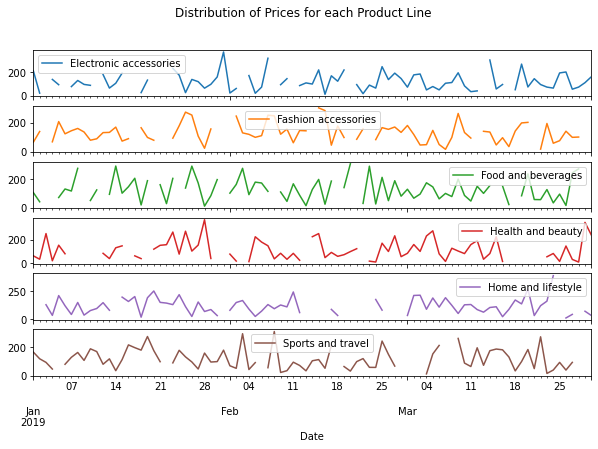

In [56]:
df_Product.plot(kind='line', subplots=True, title="Distribution of Prices for each Product Line", figsize=(10, 6)) 
df_Product

In [47]:
df_Product = pd.pivot_table(df, index= "Month", columns= "Product line", values="Unit price", aggfunc= np.sum)
df_Product

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Month,,,,,,
1,2950.21,3543.65,3237.38,2857.81,3337.09,3827.75
2,2938.94,3716.89,3367.99,2486.34,2100.08,2549.28
3,3214.62,2912.81,3140.17,2993.73,3413.54,3083.85


Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Date,,,,,,
2019-01-01,212.15,65.74,105.75,62.87,47.59,165.85
2019-01-02,22.01,140.43,41.66,34.21,NaN,118.77
2019-01-03,NaN,NaN,NaN,252.04,130.24,93.38
2019-01-04,138.82,68.71,NaN,20.97,35.54,46.42
2019-01-05,93.88,209.30,71.20,153.58,211.68,NaN
...,...,...,...,...,...,...
2019-03-26,202.16,142.37,16.31,146.39,12.29,39.12
2019-03-27,55.67,99.82,242.73,32.46,44.34,93.39
2019-03-28,73.67,101.83,269.67,10.08,NaN,NaN


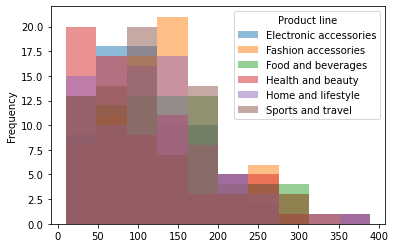

In [57]:
df_Product.plot.hist(alpha=0.5)
df_Product

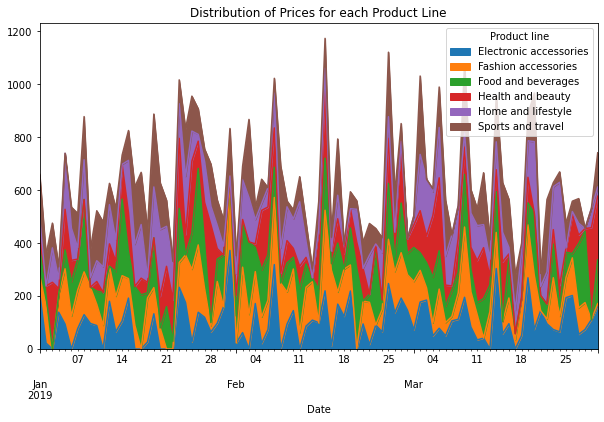

In [58]:
df_Product.plot.area(figsize=(10, 6), title="Distribution of Prices for each Product Line")

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Date,,,,,,
2019-01-01,212.15,65.74,105.75,62.87,47.59,165.85
2019-01-02,22.01,140.43,41.66,34.21,NaN,118.77
2019-01-03,NaN,NaN,NaN,252.04,130.24,93.38
2019-01-04,138.82,68.71,NaN,20.97,35.54,46.42
2019-01-05,93.88,209.30,71.20,153.58,211.68,NaN
...,...,...,...,...,...,...
2019-03-26,202.16,142.37,16.31,146.39,12.29,39.12
2019-03-27,55.67,99.82,242.73,32.46,44.34,93.39
2019-03-28,73.67,101.83,269.67,10.08,NaN,NaN


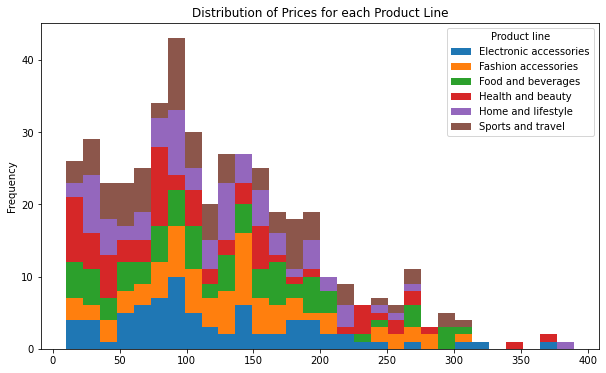

In [59]:
df_Product.plot.hist(stacked=True, bins=30, title="Distribution of Prices for each Product Line", figsize=(10, 6))
df_Product

In [42]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y %H:%M')
df['Month'] = df['Date'].dt.month

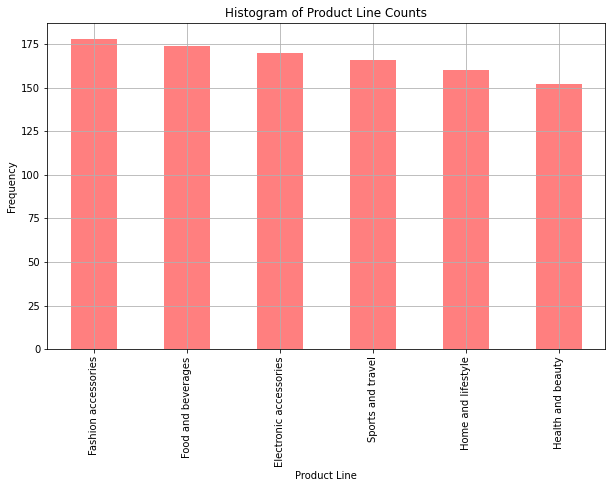

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have a DataFrame called df with a column 'Product line'
# Calculate the value counts of each unique product line
product_line_counts = df['Product line'].value_counts()

# Create a histogram-like bar plot for the counts
plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
product_line_counts.plot(kind='bar', color='r', alpha=0.5)
plt.xlabel('Product Line')
plt.ylabel('Frequency')
plt.title('Histogram of Product Line Counts')
plt.grid(True)
plt.show()


In [62]:
df_Product


Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Date,,,,,,
2019-01-01,212.15,65.74,105.75,62.87,47.59,165.85
2019-01-02,22.01,140.43,41.66,34.21,NaN,118.77
2019-01-03,NaN,NaN,NaN,252.04,130.24,93.38
2019-01-04,138.82,68.71,NaN,20.97,35.54,46.42
2019-01-05,93.88,209.30,71.20,153.58,211.68,NaN
...,...,...,...,...,...,...
2019-03-26,202.16,142.37,16.31,146.39,12.29,39.12
2019-03-27,55.67,99.82,242.73,32.46,44.34,93.39
2019-03-28,73.67,101.83,269.67,10.08,NaN,NaN


Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Date,,,,,,
2019-01-01,212.15,65.74,105.75,62.87,47.59,165.85
2019-01-02,22.01,140.43,41.66,34.21,NaN,118.77
2019-01-03,NaN,NaN,NaN,252.04,130.24,93.38
2019-01-04,138.82,68.71,NaN,20.97,35.54,46.42
2019-01-05,93.88,209.30,71.20,153.58,211.68,NaN
...,...,...,...,...,...,...
2019-03-26,202.16,142.37,16.31,146.39,12.29,39.12
2019-03-27,55.67,99.82,242.73,32.46,44.34,93.39
2019-03-28,73.67,101.83,269.67,10.08,NaN,NaN


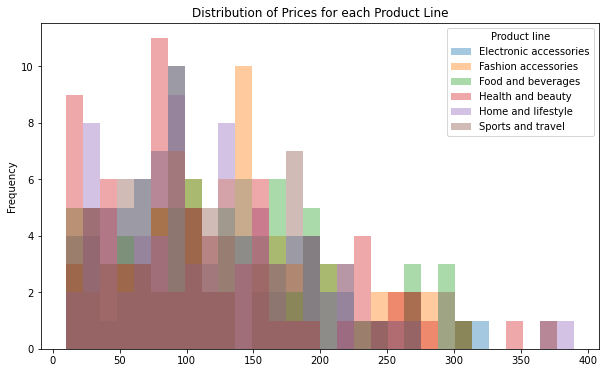

In [63]:
df_Product.plot.hist(alpha=0.4, bins=30, title="Distribution of Prices for each Product Line", figsize=(10, 6))
df_Product

In [64]:
# From the result, we can see that the most expensive goods are among "Fashion accessories", and the least expensive goods are among "Health and beauty".
Electronic = len(df_Product.loc[df_Product ["Electronic accessories"] > 90])
Fashion = len(df_Product.loc[df_Product ["Fashion accessories"] > 90])
Food_beverages = len(df_Product.loc[df_Product ["Food and beverages"] > 90])
Health_beauty = len(df_Product.loc[df_Product ["Health and beauty"] > 90])
Home_lifestyle = len(df_Product.loc[df_Product ["Home and lifestyle"] > 90])
Sports_travel = len(df_Product.loc[df_Product ["Sports and travel"] > 90])

print("Electronic_accessories = ", Electronic,"; " "Fashion_accessories = ", Fashion,"; " "Food_beverages = ", Food_beverages,"; " "Health_beauty = ", Health_beauty,"; "
     "Home_lifestyle = ", Home_lifestyle,"; " "Sports_travel = ", Sports_travel)


Electronic_accessories =  46 ; Fashion_accessories =  56 ; Food_beverages =  50 ; Health_beauty =  36 ; Home_lifestyle =  44 ; Sports_travel =  49


In [65]:
a=df

In [66]:
a.sort_values('Rating',ascending=False, inplace=True)

In [67]:
a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 387 to 876
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-null

In [68]:
a.describe()

,Unit price,Quantity,Tax 5%,Total,Date,cogs,gross margin percentage,gross income,Rating,Month
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905e+00,15.379369,6.97270,1.993000
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905e+00,0.508500,4.00000,1.000000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905e+00,5.924875,5.50000,1.000000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905e+00,12.088000,7.00000,2.000000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905e+00,22.445250,8.50000,3.000000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905e+00,49.650000,10.00000,3.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,6.131498e-14,11.708825,1.71858,0.835254


In [69]:
#Mode of Payment
a['Payment'].value_counts()

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

In [70]:
#Details of Unit Price of the Products
b=a[a['Unit price']>=99.8]
b['Unit price'].sort_values(ascending=False)

983    99.96
122    99.96
930    99.92
494    99.89
283    99.83
300    99.82
941    99.82
Name: Unit price, dtype: float64

In [71]:
# Type of Customers in Mandalay

In [72]:
c= a[a['City']== 'Mandalay'] #Specifying the city in which we need to focus on
c=c[c['Customer type']=='Member'] #Checking for the values where Member is true
c['Gender'].value_counts()#Counting the values of males and females

Gender
Female    85
Male      80
Name: count, dtype: int64

In [73]:
#Ratings of Electronic Accessories
d=a[a['City']=='Naypyitaw']
d= d[d['Product line']== 'Electronic accessories'] #Specifying the city in which we need to focus on
d=d[d['Rating']>=9] #Checking for the values where Member is true
d['Rating']

421    9.8
202    9.8
227    9.7
206    9.7
1      9.6
338    9.5
222    9.4
59     9.3
109    9.2
737    9.0
Name: Rating, dtype: float64

In [74]:
#Highest Amount of Shopping
e=a[a['Payment']=='Credit card']
e['Total'].sort_values(ascending=False).head()

350    1042.650
167    1039.290
792    1022.385
422    1020.705
122     944.622
Name: Total, dtype: float64

In [76]:
#Highest Shopping Amount
f=a[a['Customer type']=='Member']
f=f.sort_values('Total',ascending=False)
f['Total'].head()

350    1042.650
557    1034.460
422    1020.705
429     951.825
141     950.250
Name: Total, dtype: float64

Text(0.5, 1.0, 'Highest Amount Spend By Customer Having Membership')

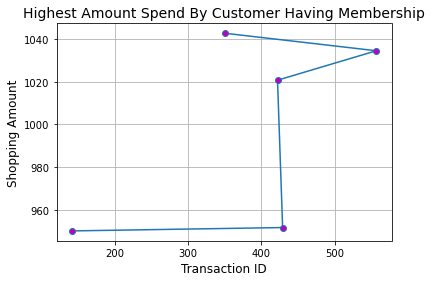

In [77]:
x=f['Total'].head()

plt.plot(x,marker='o',mfc='m') #Giving specifications for the plot chart 

plt.grid() #Adding grid for better interpretation of no.
plt.ylabel("Shopping Amount",fontsize=12) #Adding label for y axis
plt.xlabel("Transaction ID",fontsize=12) #Adding label for x axis
plt.title("Highest Amount Spend By Customer Having Membership",fontsize=14) #Giving title, specifying fontsize

In [78]:
#Highest Gross Income By Female Customers
g=a[a['City']=='Naypyitaw']
g=g[g['Gender']=='Female']
g=g[g['Product line']=='Sports and travel']
g=g.sort_values('gross income',ascending=False)
g['gross income'].head()

357    47.7200
140    44.9000
721    40.7835
154    32.3880
690    31.5855
Name: gross income, dtype: float64

Text(0, 0.5, 'Gross Income')

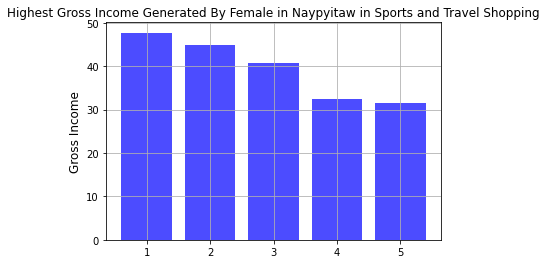

In [79]:
x=[1,2,3,4,5]
y=g['gross income'].head()

plt.bar(x,y,color='b',alpha=0.7) #alpha func to reduce the color intensity of the bar graph
plt.grid()
plt.title("Highest Gross Income Generated By Female in Naypyitaw in Sports and Travel Shopping")
plt.ylabel("Gross Income",fontsize=12) 

In [80]:
#Comparision of Health and Beauty Product
h=a[a['Product line']=='Health and beauty']

y=h[h['Gender']=='Male']
z=h[h['Gender']=='Female']

y=y.sort_values('Total',ascending=False)
z=z.sort_values('Total',ascending=False)

#y['Total'].head()
#z['Total'].head()

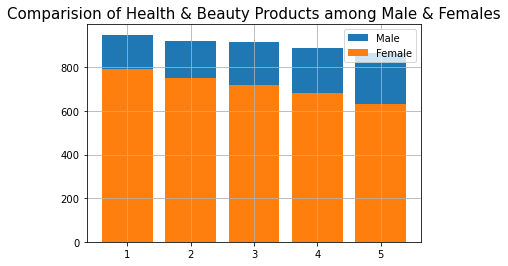

In [81]:
x=[1,2,3,4,5]
y=y['Total'].head()
z=z['Total'].head()

plt.bar(x,y,label="Male")
plt.bar(x,z,label="Female")

plt.grid()
plt.title("Comparision of Health & Beauty Products among Male & Females",fontsize=15)
plt.legend()
plt.show()

In [82]:
#No. of Shoppers in Each Branch
a['City'].value_counts()


City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

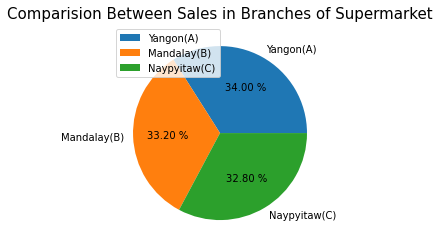

In [84]:
x=a['City'].value_counts()

plt.pie(x,labels=['Yangon(A)','Mandalay(B)','Naypyitaw(C)'],autopct="%0.2f %%")

plt.title("Comparision Between Sales in Branches of Supermarket",fontsize=15)
plt.legend(loc=2)
plt.show()

In [6]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [8]:
import pymongo
from pymongo import MongoClient
con = pymongo.MongoClient("mongodb://localhost:27017/")
db = con.DCSTEC
collection = db.Sales

In [9]:
data = df.to_dict(orient='records')
collection.insert_many(data)